In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

print("تم استيراد المكتبات بنجاح!")

تم استيراد المكتبات بنجاح!


In [4]:
# تحميل البيانات الخام
data = pd.read_csv('sales-data-sample.csv')

# عرض أول 5 أسطر للتأكد من التحميل
data.head()

,OrderDate,Category,City,Country,CustomerName,Discount,OrderID,PostalCode,ProductName,Profit,...,DaystoShipActual,SalesForecast,ShipStatus,DaystoShipScheduled,OrderProfitable,SalesperCustomer,ProfitRatio,SalesaboveTarget,latitude,longitude
0,2011-01-04T00:00:00.000Z,Office Supplies,Houston,United States,Darren Powers,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,...,4,22,Shipped Early,6,NaN,16.45,33.8,NaN,29.8941,-95.6481
1,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,Avery 508,4,...,4,15,Shipped Early,6,NaN,11.78,36.3,NaN,41.7662,-88.1410
2,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,...,4,5,Shipped Early,6,NaN,3.54,-155.0,NaN,41.7662,-88.1410
3,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,...,4,357,Shipped Early,6,NaN,272.74,-23.8,NaN,41.7662,-88.1410
4,2011-01-06T00:00:00.000Z,Office Supplies,Philadelphia,United States,Mick Brown,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,...,7,26,Shipped Late,6,NaN,19.54,25.0,NaN,39.9448,-75.2288


In [5]:
# 1. تحويل التواريخ إلى صيغة مفهومة
data['OrderDate'] = pd.to_datetime(data['OrderDate'])
data['ShipDate'] = pd.to_datetime(data['ShipDate'])

# 2. حذف القيم المفقودة في الأعمدة المهمة
data.dropna(subset=['Sales', 'Profit', 'OrderDate'], inplace=True)

# 3. إزالة القيم الشاذة (Outliers) للمبيعات (اختياري حسب ملفك)
data = data[(zscore(data['Sales'].fillna(0)) < 3)]

print("تم تنظيف البيانات بنجاح!")
data.info() # لعرض ملخص عن البيانات بعد التنظيف

تم تنظيف البيانات بنجاح!
<class 'pandas.core.frame.DataFrame'>
Index: 9867 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   OrderDate            9867 non-null   datetime64[ns, UTC]
 1   Category             9867 non-null   object             
 2   City                 9867 non-null   object             
 3   Country              9867 non-null   object             
 4   CustomerName         9867 non-null   object             
 5   Discount             9867 non-null   float64            
 6   OrderID              9867 non-null   object             
 7   PostalCode           9867 non-null   int64              
 8   ProductName          9867 non-null   object             
 9   Profit               9867 non-null   int64              
 10  Quantity             9867 non-null   int64              
 11  Region               9867 non-null   object             
 12  

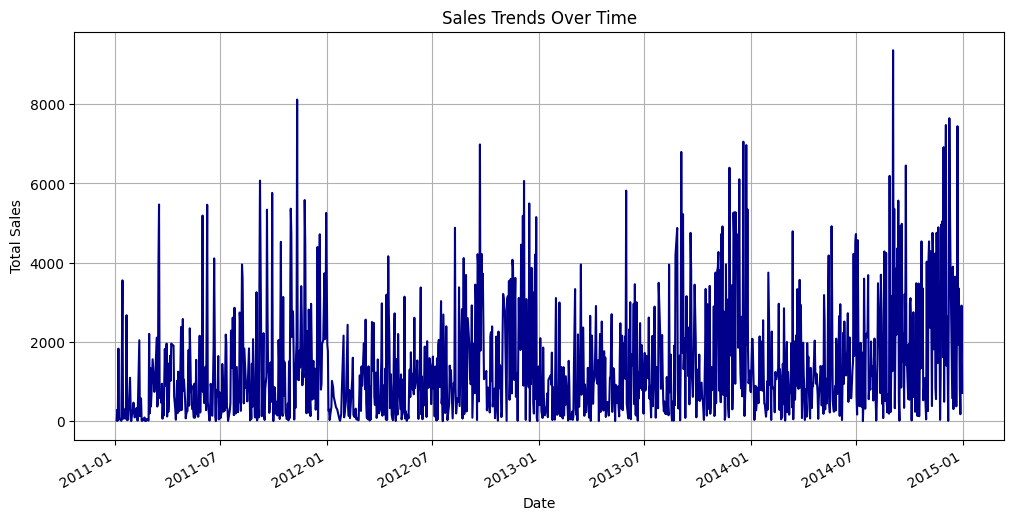

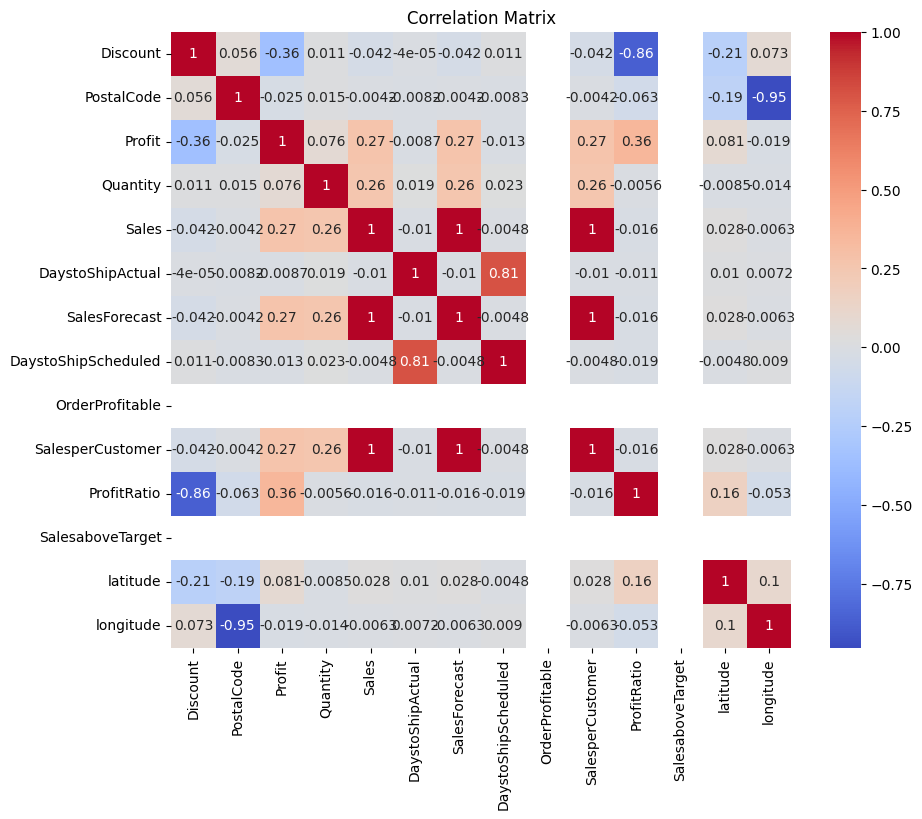

In [6]:
# رسم اتجاه المبيعات عبر الزمن
plt.figure(figsize=(12, 6))
data.groupby('OrderDate')['Sales'].sum().plot(kind='line', color='darkblue')
plt.title('Sales Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# رسم مصفوفة الارتباط لمعرفة العلاقات بين الأرقام
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [7]:
# حفظ الملف النهائي
data.to_csv('cleaned_data.csv', index=False)
print("تم حفظ الملف باسم 'cleaned_data.csv'. يمكنك الآن استيراده في Power BI.")

تم حفظ الملف باسم 'cleaned_data.csv'. يمكنك الآن استيراده في Power BI.
